## 01. CatBoost 개념 정리

CatBoost는 categorical boosting에서 이름이 온 Gradient Boosting 계열 라이브러리임.  
범주형 feature를 직접 지정해 모델 내부에서 처리할 수 있다는 점이 큰 특징임.

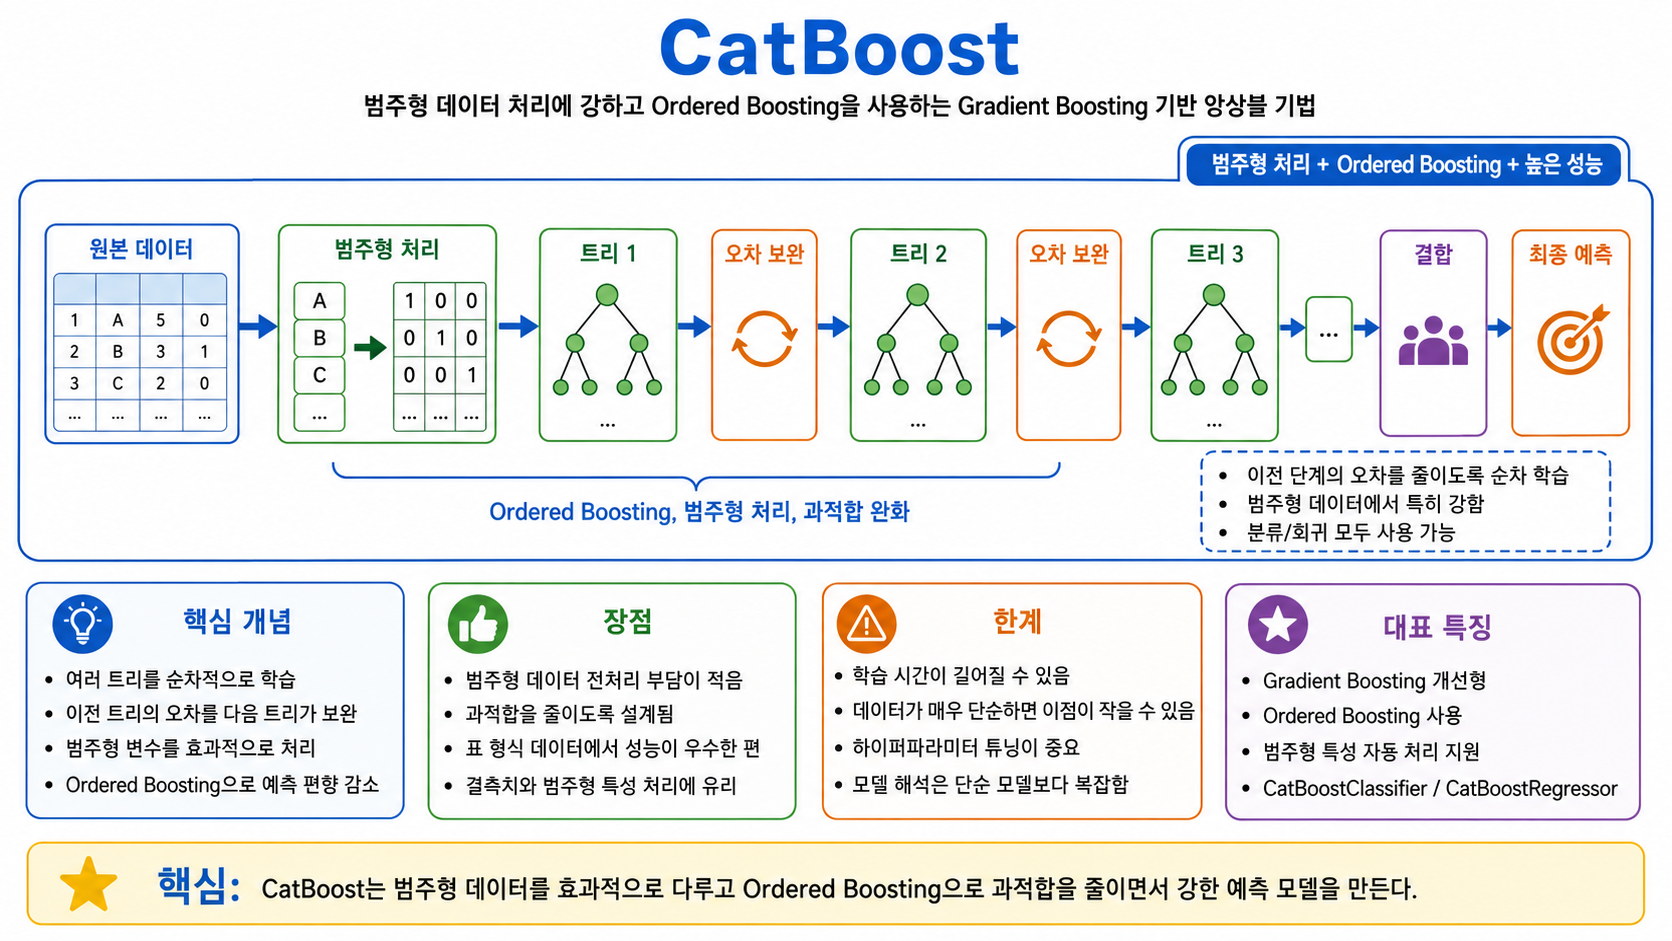

### 01-01. 배우는 이유

- 실무 데이터에는 문자열 범주형 컬럼이 많은 경우가 흔함.
- CatBoost는 범주형 feature를 별도 OneHotEncoder 없이 다룰 수 있어 전처리 부담을 줄일 수 있음.
- XGBoost, LightGBM과 함께 외부 Boosting 라이브러리의 차이를 비교하기 좋음.

### 01-02. 어디서 사용하는가?

- 성별, 지역, 직업, 상품 카테고리처럼 범주형 feature가 많은 표 데이터 문제에서 사용함.
- 클릭 예측, 구매 예측, 신용 위험, 고객 등급 분류 같은 실무 분류 문제에 활용됨.
- 인코딩 방식에 따라 성능 차이가 큰 데이터에서 후보 모델로 검토함.

### 01-03. 핵심 특징

- 범주형 feature를 `cat_features`로 지정할 수 있음.
- 문자열 범주형 컬럼을 별도 OneHotEncoder 없이 다룰 수 있어 실무 데이터에서 편리함.
- 기존 모델은 문자열 범주형 feature를 숫자로 바꾸는 전처리가 필요하지만, CatBoost는 원본 범주형 컬럼을 직접 다룰 수 있음.
- `CatBoostClassifier`를 사용하려면 CatBoost 라이브러리가 설치되어 있어야 함.

### 01-04. 이번 노트북에서 확인할 개선점

- 간단한 예제로 `cat_features` 지정 방식을 확인함.
- Adult Income 데이터에서 기존 모델은 one-hot encoding 후 학습하고, CatBoost는 원본 범주형 feature를 직접 사용해 학습함.
- 비교 결과를 통해 CatBoost의 장점이 단순히 점수만이 아니라 전처리 부담 감소에도 있음을 확인함.


In [1]:
# %pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 6.3 MB/s eta 0:00:16
   - -------------------------------------- 3.1/100.2 MB 9.2 MB/s eta 0:00:11
   -- ------------------------------------- 6.3/100.2 MB 11.4 MB/s eta 0:00:09
   ----- ---------------------------------- 14.7/100.2 MB 19.2 MB/s eta 0:00:05
   -------- ------------------------------- 21.2/100.2 MB 22.0 MB/s eta 0:00:04
   ----------- ---------------------------- 29.1/100.2 MB 24.9 MB/s eta 0:00:03
   -------------- ------------------------- 35.9/100.2 MB 26.2 MB/s eta 0:00:03
   ------------------ --------------------- 46.7/100.2 MB 29.7 MB/s eta 0:00:02
   --------------------- ------------------ 55.1/100.2 MB 30.8 MB/s eta 0:00:02
   --------------------------- ------------ 67.9/100.2 MB 34.4 MB/s eta 0:00:01
   ------------------------------- -------- 77.9/100.2 MB 35.5 MB/s eta 0:00:01
   ------------------------------------ --- 91.0/100.2

## 02. 실습 환경 준비

In [1]:
# pathlib.Path: 운영체제에 덜 의존적인 방식으로 파일 경로를 다루기 위해 사용
from pathlib import Path

# 데이터 처리에 사용할 기본 라이브러리
import numpy as np
import pandas as pd

# train_test_split: 학습 데이터와 평가 데이터를 분리
from sklearn.model_selection import train_test_split

# accuracy_score: 분류 정확도 계산
# classification_report: precision, recall, f1-score를 class별로 출력
from sklearn.metrics import accuracy_score, classification_report

# CatBoost와 비교할 기존 분류 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# CatBoostClassifier: CatBoost의 분류 모델
# CatBoost는 문자열 범주형 feature를 비교적 편하게 다룰 수 있는 Boosting 계열 모델임.
# CatBoost 라이브러리를 직접 import해 이후 예제에서 바로 사용함.
from catboost import CatBoostClassifier

## 03. 간단한 범주형 데이터 예제

- CatBoost는 범주형 컬럼명을 `cat_features`에 전달할 수 있음.
- 예제에서는 `city`, `device` 같은 문자열 feature를 그대로 사용함.


In [3]:
# city, device는 문자열 범주형 feature이고, visit_count는 수치 feature임.
# purchase는 모델이 맞혀야 할 target이며 1은 구매, 0은 미구매를 의미함.
simple_df = pd.DataFrame({
    'city': ['Seoul', 'Busan', 'Seoul', 'Daegu', 'Busan', 'Seoul', 'Daegu', 'Busan'],
    'device': ['mobile', 'pc', 'pc', 'mobile', 'mobile', 'mobile', 'pc', 'pc'],
    'visit_count': [5, 2, 7, 1, 3, 8, 2, 4],
    'purchase': [1, 0, 1, 0, 0, 1, 0, 1]
})

# simple_X: 모델 입력 feature. 문자열 feature와 수치 feature가 함께 있음.
# simple_y: 구매 여부 target.
simple_X = simple_df.drop('purchase', axis=1)
simple_y = simple_df['purchase']

display(simple_df)
print(simple_X.dtypes)
print(simple_y.value_counts())



,city,device,visit_count,purchase
0,Seoul,mobile,5,1
1,Busan,pc,2,0
2,Seoul,pc,7,1
3,Daegu,mobile,1,0
4,Busan,mobile,3,0
5,Seoul,mobile,8,1
6,Daegu,pc,2,0
7,Busan,pc,4,1


city             str
device           str
visit_count    int64
dtype: object
purchase
1    4
0    4
Name: count, dtype: int64


In [4]:
cat_model = CatBoostClassifier(
    iterations=50, # boosting 반복 횟수 == 트리 생성 개수
    depth=3,
    learning_rate=0.1,
    random_state=42,
    verbose=False # 학습 로그 숨기기
)

# cat_features=['city', 'device']
# - 문자열이 저장된 컬럼을 범주형 feature로 인식시켜 학습을 하게 만듦
# -> 내부적으로 OneHotEncoding이 자동으로 수행
cat_model.fit(simple_X, simple_y, cat_features=['city', 'device'])

simple_pred = cat_model.predict(simple_X)
print("accuracy: ", accuracy_score(simple_y, simple_pred))

accuracy:  1.0


## 04. Adult Income 데이터 준비와 모델 비교

Adult Income 데이터는 나이, 직업, 교육, 근무시간 등으로 소득 수준을 분류하는 데이터임.  
범주형 feature가 많아 CatBoost의 장점을 설명하기 좋음.

이번 비교에서는 두 가지 흐름을 나란히 확인함.

- 기존 scikit-learn 모델: 문자열 범주형 feature를 `pd.get_dummies()`로 one-hot encoding한 뒤 학습함.
- CatBoost: 원본 문자열 범주형 feature를 유지하고 `cat_features`에 컬럼명을 지정해 학습함.

따라서 결과 표에서는 성능뿐 아니라 `preprocessing` 컬럼도 함께 확인해야 함.


In [5]:
# 실행 위치가 노트북 서버/IDE에 따라 달라질 수 있으므로 여러 후보 경로를 확인함.
# 먼저 현재 노트북 폴더 기준 data/adult_income.csv를 찾고, 없으면 다른 후보를 차례대로 확인함.
data_candidates = [
    Path('data/adult_income.csv'),
]

# next(..., None): 존재하는 첫 번째 경로를 찾고, 없으면 None을 반환함.
adult_path = next((path for path in data_candidates if path.exists()), None)

if adult_path is None:
    raise FileNotFoundError('adult_income.csv를 찾지 못했습니다. 05_ensemble/data 폴더의 CSV 경로를 확인하세요.')

# Adult Income CSV는 헤더가 없는 파일이므로 컬럼명을 직접 지정함.
adult_columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# pd.read_csv(..., names=adult_columns): 헤더가 없는 CSV에 컬럼명을 붙여 읽어옴.
adult_df = pd.read_csv(adult_path, names=adult_columns, header=None)

# 문자열 값 앞에 공백이 포함되어 있으므로 strip()으로 정리함.
for col in adult_df.columns:
    if pd.api.types.is_string_dtype(adult_df[col]) or pd.api.types.is_object_dtype(adult_df[col]):
        adult_df[col] = adult_df[col].astype(str).str.strip()

display(adult_df.head())
print(adult_df.shape)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


(32561, 15)


In [6]:
target_col = 'income' if 'income' in adult_df.columns else adult_df.columns[-1]

adult_X_raw = adult_df.drop(target_col, axis=1).replace('?', 'Unknown')
adult_y = adult_df[target_col]

cat_features = [
    col for col in adult_X_raw.columns
    if pd.api.types.is_string_dtype(adult_X_raw[col]) or pd.api.types.is_object_dtype(adult_X_raw[col])
]

# 기존 scikit-learn 모델은 문자열 feature를 직접 학습할 수 없으므로 one-hot encoding을 적용함.
# CatBoost와 같은 train/test 분할을 사용하기 위해 원본 feature와 encoding feature를 함께 분할함.
# get_dummies(): 범주형 컬럼을 여러 개의 0/1 컬럼으로 바꿈.
adult_X_encoded = pd.get_dummies(adult_X_raw, dummy_na=True)

# train_test_split()은 여러 배열을 한 번에 넣으면 같은 인덱스 기준으로 함께 분리함.
# 여기서는 CatBoost용 원본 feature와 기존 모델용 one-hot feature를 같은 기준으로 나눔.
(
    adult_X_train_raw,
    adult_X_test_raw,
    adult_X_train_encoded,
    adult_X_test_encoded,
    adult_y_train,
    adult_y_test,
) = train_test_split(
    adult_X_raw,
    adult_X_encoded,
    adult_y,
    test_size=0.2,
    random_state=42,
    stratify=adult_y if adult_y.nunique() < 20 else None
)


In [7]:
# 기존 모델과 CatBoost 비교
baseline_models = {
    "decistion_tree_onehot": DecisionTreeClassifier(
        random_state=42,
        max_depth=8
    ),
    "random_forest_onehot": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=1
    ),
    "gradient_boosting_onehot": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        random_state=42,
    ),
}

catboost_results = []

for name, model in baseline_models.items():
    model.fit(adult_X_train_encoded, adult_y_train)

    catboost_results.append({
        'model': name,
        'preprocessing': 'one-hot encoding 필요',
        'train_accuracy': model.score(adult_X_train_encoded, adult_y_train),
        'test_accuracy': model.score(adult_X_test_encoded, adult_y_test),
    })

# CatBoostClassifier()
adult_model = CatBoostClassifier(
    iterations=200,
    depth=5,
    learning_rate=0.08,
    verbose=False,
    random_state=42
)

# fit(..., cat_features=cat_features): 지정한 문자열 컬럼을 CatBoost 방식으로 내부 처리하며 학습
adult_model.fit(adult_X_train_raw, adult_y_train, cat_features=cat_features)

adult_pred = np.ravel(adult_model.predict(adult_X_test_raw))

catboost_results.append({
    'model': 'catboost_raw_category',
    'preprocessing': 'cat_features 지정',
    'train_accuracy': accuracy_score(adult_y_train, np.ravel(adult_model.predict(adult_X_train_raw))),
    'test_accuracy': accuracy_score(adult_y_test, adult_pred),
})

# sort_values('test_accuracy'): 평가 점수가 높은 모델부터 정렬함.
catboost_result_df = pd.DataFrame(catboost_results).sort_values('test_accuracy', ascending=False)
display(catboost_result_df)

# 기존 모델 중 가장 좋은 test_accuracy와 CatBoost test_accuracy를 따로 비교함.
best_existing_accuracy = catboost_result_df.query("model != 'catboost_raw_category'")['test_accuracy'].max()
catboost_accuracy = catboost_result_df.loc[
    catboost_result_df['model'] == 'catboost_raw_category',
    'test_accuracy'
].iloc[0]

print('범주형 feature:', cat_features)
print(f'기존 모델 최고 test_accuracy: {best_existing_accuracy:.4f}')
print(f'CatBoost test_accuracy: {catboost_accuracy:.4f}')
print(f'차이: {catboost_accuracy - best_existing_accuracy:.4f}')
print()

print(classification_report(adult_y_test, adult_pred))

,model,preprocessing,train_accuracy,test_accuracy
3,catboost_raw_category,cat_features 지정,0.878954,0.875940
2,gradient_boosting_onehot,one-hot encoding 필요,0.871698,0.870106
0,decistion_tree_onehot,one-hot encoding 필요,0.860527,0.858898
1,random_forest_onehot,one-hot encoding 필요,0.857148,0.855213


범주형 feature: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
기존 모델 최고 test_accuracy: 0.8701
CatBoost test_accuracy: 0.8759
차이: 0.0058

              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      4945
        >50K       0.79      0.66      0.72      1568

    accuracy                           0.88      6513
   macro avg       0.84      0.80      0.82      6513
weighted avg       0.87      0.88      0.87      6513



## 05. CatBoost 정리

- CatBoost는 범주형 feature 처리에 강점이 있는 Gradient Boosting 라이브러리임.
- 문자열 범주형 feature를 `cat_features`로 지정할 수 있음.
- 기존 scikit-learn 모델은 보통 one-hot encoding 같은 전처리가 필요하지만, CatBoost는 범주형 컬럼을 직접 다룰 수 있음.
- 이번 예제에서는 기존 모델과 CatBoost를 같은 Adult Income 데이터에서 비교해 성능과 전처리 차이를 함께 확인함.
- CatBoost가 항상 최고라는 뜻은 아니며, 범주형 변수가 많은 표 데이터에서 강한 후보 모델로 검토하기 좋음.
